In [2]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

import torch

In [3]:
DELTA = 1.5
MOT_W, MOT_H = 35.0, 42.0 
RACK_W = 8.0 
RACK_H_FULL = 70.0 
RACK_H_CASING = 69.0  # Рабочая длина рейки в корпусе

# Радиус описанной вокруг мотора окружности (для проверки зазора с D40)
R_MOT = np.hypot(MOT_W / 2.0, MOT_H / 2.0)

PENALTY_WEIGHT = 8000
BATCH_SIZE = 1000000

In [4]:
def layout(theta, sides): #theta - матрица весов, в нашем случае углы расстояний между колесами
    alpha, beta, gamma, shift = theta[:, 0], theta[:, 1], theta[:, 2], theta[:, 3]    
    x1 = torch.zeros_like(alpha)
    y1 = torch.zeros_like(alpha) #зафиксирвоанное положение первого колеса

    x2 = x1 + 15.0 * torch.cos(alpha)
    y2 = y1 + 15.0 * torch.sin(alpha)

    x3 = x2 + 20.0 * torch.cos(beta)
    y3 = y2 + 20.0 * torch.sin(beta)

    x4 = x3 + 30.0 * torch.cos(gamma) #сказали больше комменатриев делать но тут врод ясно ды
    y4 = y3 + 30.0 * torch.sin(gamma) 

    rack_cx = x4 + sides * (20.0 + RACK_W / 2.0)
    rack_cy = y4 + shift
    rack_x1 = rack_cx - RACK_W / 2.0
    rack_x2 = rack_cx + RACK_W / 2.0

    rack_casing = (rack_x1, rack_x2, rack_cy - RACK_H_CASING / 2.0, rack_cy + RACK_H_CASING / 2.0)
    rack_full = (rack_x1, rack_x2, rack_cy - RACK_H_FULL / 2.0, rack_cy + RACK_H_FULL / 2.0)
    
    axes = ((x1, y1), (x2, y2), (x3, y3), (x4, y4))
    return axes, rack_casing, rack_full
    

In [5]:
def get_bounding_box(axes, rack_casing):
    (x1, y1), (x2, y2), (x3, y3), (x4, y4) = axes
    rx1, rx2, ry1_cas, ry2_cas = rack_casing
    mot_w_tensor = torch.full_like(x1, MOT_W / 2.0)
    mot_h_tensor = torch.full_like(x1, MOT_H / 2.0)
    #по факту дальше мы закинем все точки в массив, а в нем найдем крайние точки и там площадь бах бах 
    xs_min = torch.stack([-mot_w_tensor, x2 - 10.0, x3 - 15.0, x4 - 25.0, rx1], dim=1)
    xs_max = torch.stack([ mot_w_tensor, x2 + 10.0, x3 + 15.0, x4 + 25.0, rx2], dim=1)

    ys_min = torch.stack([-mot_h_tensor, y2 - 10.0, y3 - 15.0, y4 - 25.0, ry1_cas], dim=1)
    ys_max = torch.stack([ mot_h_tensor, y2 + 10.0, y3 + 15.0, y4 + 25.0, ry2_cas], dim=1)

    width = torch.max(xs_max, dim=1).values - torch.min(xs_min, dim=1).values
    height = torch.max(ys_max, dim=1).values - torch.min(ys_min, dim=1).values

    return width, height

In [6]:
def check_collisions(axes, rack_full):
    (x1, y1), (x2, y2), (x3, y3), (x4, y4) = axes
    rx1, rx2, ry1_full, ry2_full = rack_full

    d13 = torch.hypot(x3 - x1, y3 - y1)
    loss_13 = torch.relu(24.0 - d13) ** 2 #вы поняли да если коллизия то релушечка родная даст ошибку хорошую

    d24 = torch.hypot(x4 - x2, y4 - y2)
    loss_24 = torch.relu(39.0 - d24) ** 2

    dx = torch.maximum(-torch.tensor(MOT_W / 2.0) - rx2, rx1 - torch.tensor(MOT_W / 2.0))
    dy = torch.maximum(-torch.tensor(MOT_H / 2.0) - ry2_full, ry1_full - torch.tensor(MOT_H / 2.0))

    # короче параллельные прямоугольники не персекаются если их разделяет прямая по какой либо из осей
    gap = torch.maximum(dx, dy)
    loss_rack_mot = torch.relu(DELTA - gap) ** 2

    d14 = torch.hypot(x4 - x1, y4 - y1)
    loss_mot_c4 = torch.relu((20.0 + R_MOT + DELTA) - d14) ** 2

    # Суммарный штраф
    total_penalty = loss_13 + loss_24 + loss_rack_mot + loss_mot_c4
    return total_penalty

In [7]:
def compute_loss(theta,sides):
    axes, rack_casing, rack_full = layout(theta,sides)
    width, height = get_bounding_box(axes, rack_casing)
    raw_penalty = check_collisions(axes, rack_full)
    
    area = width * height

    total_loss = area + PENALTY_WEIGHT * raw_penalty

    return total_loss, area, raw_penalty, (width, height)

In [8]:
# theta = torch.nn.Parameter(torch.rand(3) * 2 * np.pi) 
## так как у нас релу то He не пойдет мы вот да вот эту тему 
# theta_tensor = torch.empty(1, 3)
# torch.nn.init.kaiming_uniform_(theta_tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')
# theta = torch.nn.Parameter(theta_tensor.squeeze(0))
grid_angles = torch.linspace(0, 2 * np.pi, 35)  
grid_shift = torch.linspace(-14.5, 14.5, 10)  
grid_sides = torch.tensor([-1.0, 1.0])
full_grid = torch.cartesian_prod(grid_angles, grid_angles, grid_angles, grid_shift, grid_sides) # все варианты
theta = torch.nn.Parameter(full_grid[:, :4]) # Первые 4 колонки учим
sides = full_grid[:, 4]                      # 5-ю колонку просто используем

BATCH_SIZE = theta.shape[0]
optimizer = torch.optim.Adam([theta], lr=0.03)
print("Запуск оптимизации компоновки...")

for epoch in range(401):
    optimizer.zero_grad()

    loss, area, penalty, (w, h) = compute_loss(theta, sides)
    # loss.backward()
    loss.sum().backward()

    optimizer.step()
    # scheduler.step()

    if epoch % 200 == 0:
        best_idx = torch.argmin(loss)
        print(
            f"{epoch:4d} Loss лучшего: {loss[best_idx].item():.1f} | "
            f"Площадь: {area[best_idx].item():.1f} | Штраф: {penalty[best_idx].item():.4f}"
        )

with torch.no_grad():
    final_loss, final_area, final_pen, (final_w, final_h) = compute_loss(theta, sides)
    best_idx = torch.argmin(final_loss)
    
    best_theta = theta[best_idx]
    best_side = sides[best_idx]
    best_deg = (best_theta[:3].numpy() * 180 / np.pi) % 360

print(f"Оптимальные углы: α={best_deg[0]:.1f}°, β={best_deg[1]:.1f}°, γ={best_deg[2]:.1f}°")
print(f"Габариты: {final_w[best_idx].item():.2f} × {final_h[best_idx].item():.2f} мм")
print(f"Площадь корпуса: {final_area[best_idx].item():.1f} мм²")
print(f"Коллизии устранены: {final_pen[best_idx].item() < 1e-3}")

best_theta_for_plot = best_theta.unsqueeze(0)

Запуск оптимизации компоновки...
   0 Loss лучшего: 5062.2 | Площадь: 5062.2 | Штраф: 0.0000
 200 Loss лучшего: 4995.5 | Площадь: 4995.4 | Штраф: 0.0000
 400 Loss лучшего: 4995.5 | Площадь: 4995.4 | Штраф: 0.0000
Оптимальные углы: α=181.3°, β=94.2°, γ=72.6°
Габариты: 53.00 × 94.25 мм
Площадь корпуса: 4995.4 мм²
Коллизии устранены: True


In [ ]:
import matplotlib.pyplot as plt

def plot_gearbox(best_theta, best_side):
    with torch.no_grad():
        theta_batch = best_theta.unsqueeze(0)
        sides_batch = best_side.unsqueeze(0)
        
        axes, rack_cas, rack_full = layout(theta_batch, sides_batch)
        w, h = get_bounding_box(axes, rack_cas)
        
        (x1, y1), (x2, y2), (x3, y3), (x4, y4) = [(p[0].item(), p[1].item()) for p in axes]
        rx1, rx2, ry1, ry2 = [v[0].item() for v in rack_cas]
        
        bx = min(-MOT_W / 2, x2 - 10, x3 - 15, x4 - 25, rx1)
        by = min(-MOT_H / 2, y2 - 10, y3 - 15, y4 - 25, ry1)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.add_patch(plt.Rectangle((bx, by), w.item(), h.item(), fill=False, ls="--", lw=2, color="black", 
                               label=f"Корпус: {w.item():.1f}×{h.item():.1f} мм"))
    ax.add_patch(plt.Rectangle((-MOT_W / 2, -MOT_H / 2), MOT_W, MOT_H, color="orange", alpha=0.3, label="Мотор"))
    ax.add_patch(plt.Rectangle((rx1, ry1), RACK_W, RACK_H_CASING, color="purple", alpha=0.5, label="Рейка"))

    circles = [(x1, y1, 5), (x2, y2, 10), (x2, y2, 5), (x3, y3, 15), (x3, y3, 5), (x4, y4, 25), (x4, y4, 20)]
    for cx, cy, r in circles:
        ax.add_patch(plt.Circle((cx, cy), r, fill=False, lw=1.2, color="blue"))
    ax.plot([x1, x2, x3, x4], [y1, y2, y3, y4], "ro-", lw=1.5, label="Оси O1-O4")

    ax.set_aspect("equal")
    ax.grid(True, ls=":")
    ax.legend(loc=(1.05, 1))
    plt.title("Компоновка редуктора")
    plt.show()

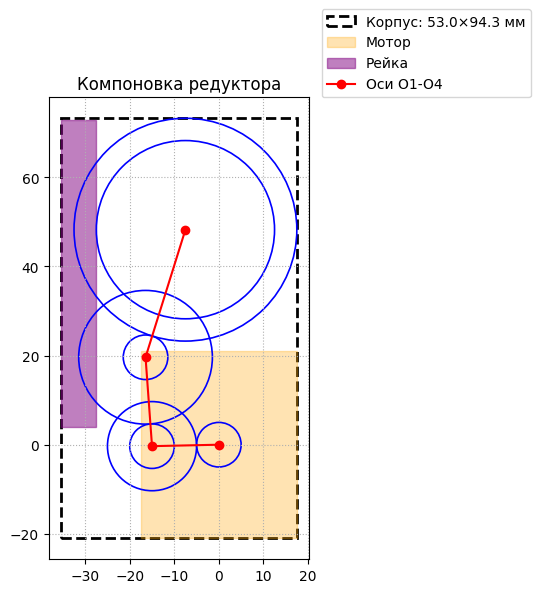

In [10]:
plot_gearbox(best_theta, best_side)